<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/WK_7_TensorflowCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
from warnings import filterwarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
filterwarnings("ignore")

In [53]:
# Download and Load the dataset into python workspace
#We are using MNIST dataset, it contains images of digits(from 0-9) and their labels
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [54]:
# Understand And Organize the Dataset
# Check data types
print(f"x_train data type: {type(x_train)}")
print(f"y_train data type: {type(y_train)}")
print(f"x_test data type: {type(x_test)}")
print(f"y_test data type: {type(y_test)}\n")

# Check shapes of the datasets
# MNIST dataset contains 60,000 training and 10,000 testing images, all 28x28 pixels
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Check unique values in target variables
# obtain unique values by removing any duplicate values of 0-9
print(f"Unique values in y_train: {np.unique(y_train)}")
print(f"Unique values in y_test: {np.unique(y_test)}\n")

# Check if there is any missing data
# no missing values in dataset as all are 'false'
print(f"Any missing values in x_train: {np.any(np.isnan(x_train))}")
print(f"Any missing values in y_train: {np.any(np.isnan(y_train))}")
print(f"Any missing values in x_test: {np.any(np.isnan(x_test))}")
print(f"Any missing values in y_test: {np.any(np.isnan(y_test))}")

x_train data type: <class 'numpy.ndarray'>
y_train data type: <class 'numpy.ndarray'>
x_test data type: <class 'numpy.ndarray'>
y_test data type: <class 'numpy.ndarray'>

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)

Unique values in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique values in y_test: [0 1 2 3 4 5 6 7 8 9]

Any missing values in x_train: False
Any missing values in y_train: False
Any missing values in x_test: False
Any missing values in y_test: False


In [55]:
#checking how many label values we have
num_labels = len(np.unique(y_train))
num_labels

10

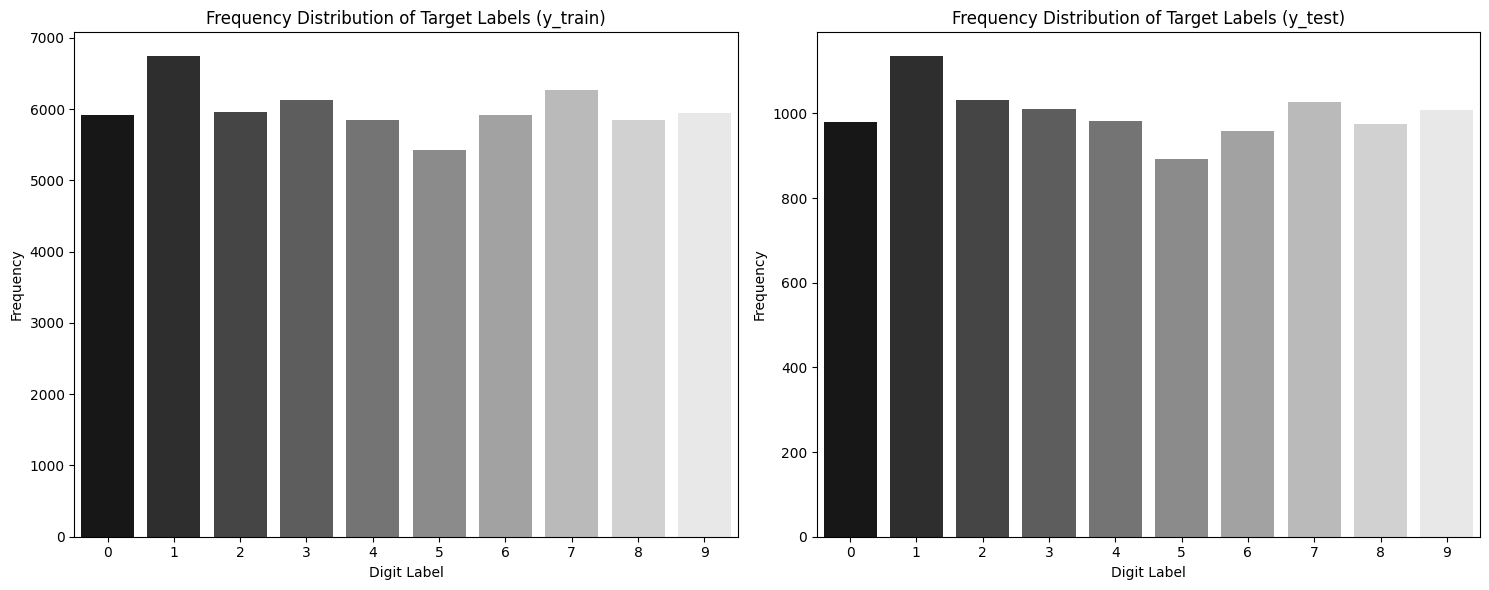

In [56]:
# Frequency Distribution of Target Labels y_train and y_test

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x=y_train, palette='gray', ax=axes[0])
axes[0].set_title('Frequency Distribution of Target Labels (y_train)')
axes[0].set_xlabel('Digit Label')
axes[0].set_ylabel('Frequency')

sns.countplot(x=y_test, palette='gray', ax=axes[1])
axes[1].set_title('Frequency Distribution of Target Labels (y_test)')
axes[1].set_xlabel('Digit Label')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#the images of the digit 1 has the highest frequency in the dataset

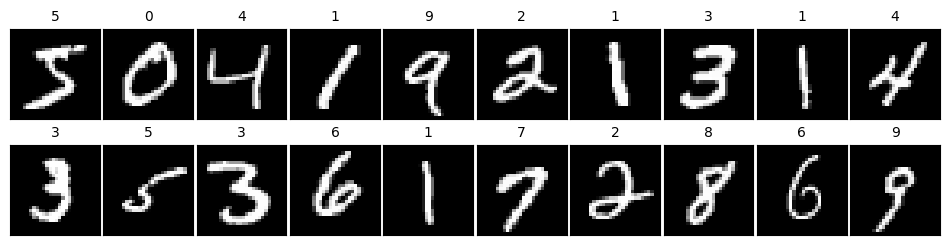

In [57]:
# Visualization of Some Digits and Their Labels

def visualize_images(data):
    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(12,3),
                             gridspec_kw={'wspace':0.04, 'hspace':0.01},
                             squeeze=True)

    for i, ax in enumerate(axes.flat):
        ax.imshow(x_train[i], cmap='gray')
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(str(y_train[i]), fontsize=10)

    plt.tight_layout()
    plt.show()

visualize_images(x_train)

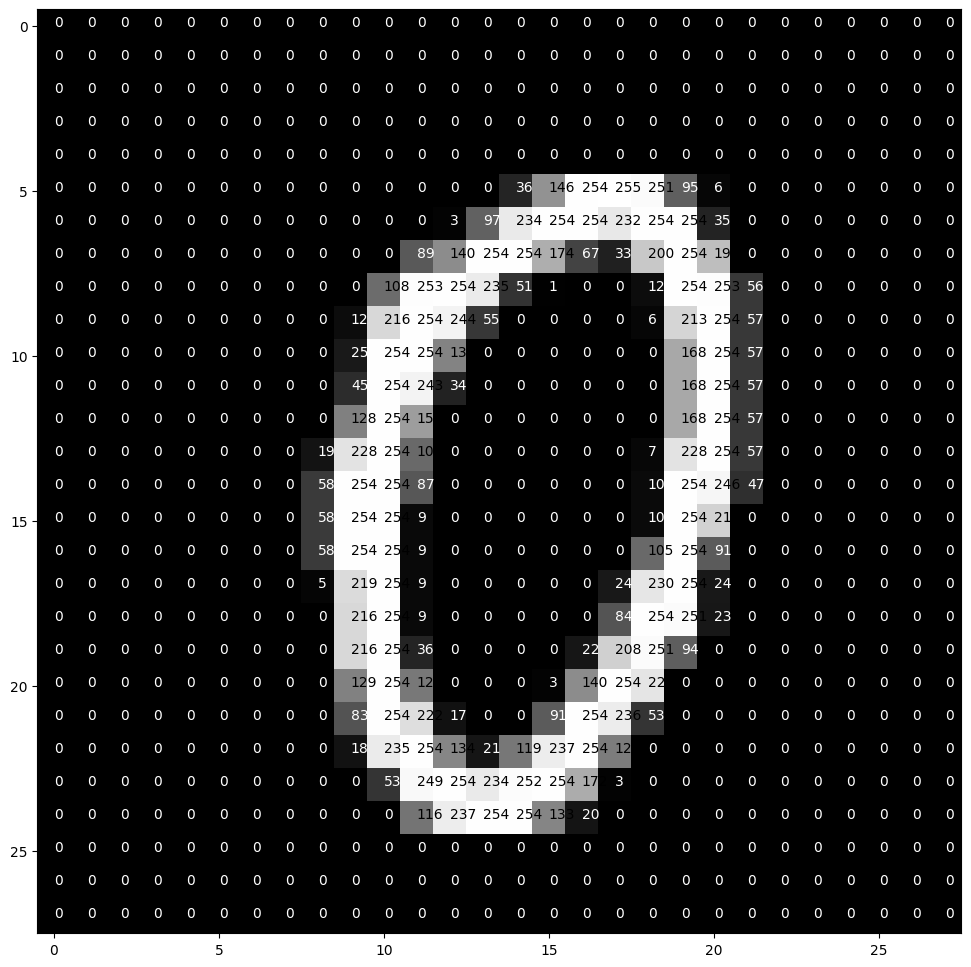

In [58]:
# Visualizing an Image with Pixel Values

def pixel_visualize(img):
    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")
    width, height = img.shape
    threshold = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y], 2)), xy=(y,x),
                       color='white' if img [x][y]<threshold else 'black')

pixel_visualize(x_train[1000])

In [59]:
# Preprocessing
#print few labels
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [60]:
#apply one hot encoding to training and test data for y
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

y_train[0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [61]:
#viewing shape of our training dataset for x
x_train.shape

#60,000 images, 28x28 pixels for each image

(60000, 28, 28)

In [62]:
#add a third dimension(it represents channels in the image, which tells the cnn if image is grayscale(1 channel) or colored (3 channels: rgb))
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

#both training and test data are greyscale (represented by 1)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [63]:
#normalizing the values of pixels in the x_train and x_test
# MNIST pixel values can range upto 255, hence dividing by 255 normalises all to value 1
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [64]:
# Model Building/Designing

model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=x_train.shape[1:]))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2))) #Maxpooling takes maximum values from each window to preserve dominant image features
model.add(BatchNormalization()) #batchnormalization increases model stability by normalizing activators
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.3)) #increasing dropout each time

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_labels, activation='softmax')) #softmax activation converts image values to probabilities for output classification

model.compile(optimizer=Adam(learning_rate=0.001),
             loss='categorical_crossentropy',
             metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "accuracy"])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 892,266 (3.40 MB)

 Trainable params: 891,050 (3.40 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [65]:
# Using ImageDataGenerator for Data Augmentation: This step increases the sample size of training dataset, to help counter overfitting

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    fill_mode='nearest'
)
datagen.fit(x_train)

In [51]:
early_stopping_callback = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(datagen.flow(x_train, y_train, batch_size=512), epochs=5,
                    validation_data=(x_test, y_test), callbacks=[early_stopping_callback])

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.9644 - loss: 0.1157 - precision_2: 0.9706 - recall_2: 0.9595 - val_accuracy: 0.9800 - val_loss: 0.0646 - val_precision_2: 0.9825 - val_recall_2: 0.9770
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9688 - loss: 0.1027 - precision_2: 0.9739 - recall_2: 0.9645 - val_accuracy: 0.9870 - val_loss: 0.0415 - val_precision_2: 0.9888 - val_recall_2: 0.9854
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9699 - loss: 0.0977 - precision_2: 0.9743 - recall_2: 0.9663 - val_accuracy: 0.9909 - val_loss: 0.0299 - val_precision_2: 0.9918 - val_recall_2: 0.9901
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9731 - loss: 0.0863 - precision_2: 0.9773 - recall_2: 0.9697 - val_accuracy: 0.9908 - val_loss: 0.0289 - val_precision_2: 0.9917 - val_recall_2: 0.9903
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.9730 - loss: 0.0879 - precision_2: 0.9768 - recall_2: 0.9700 -

In [66]:
# Results and Visualization of the Model
# argmax helps to identify position of highest values in dataset - y_predicted and y_test are input for finding their highest values
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step


In [67]:
# Classification Report

class_labels = ['0','1','2','3','4','5','6','7','8','9']
report = classification_report(y_true, y_pred_class, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           0       0.08      0.00      0.00       980
           1       0.58      0.65      0.62      1135
           2       0.02      0.01      0.01      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.02      0.02      0.02       892
           6       0.11      0.85      0.19       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.16     10000
   macro avg       0.08      0.15      0.08     10000
weighted avg       0.09      0.16      0.09     10000



In [79]:
##mean squared error
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanSquaredError()])

model.fit(x_train, y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 228s 120ms/step - loss: 0.0083 - mean_squared_error: 0.0083


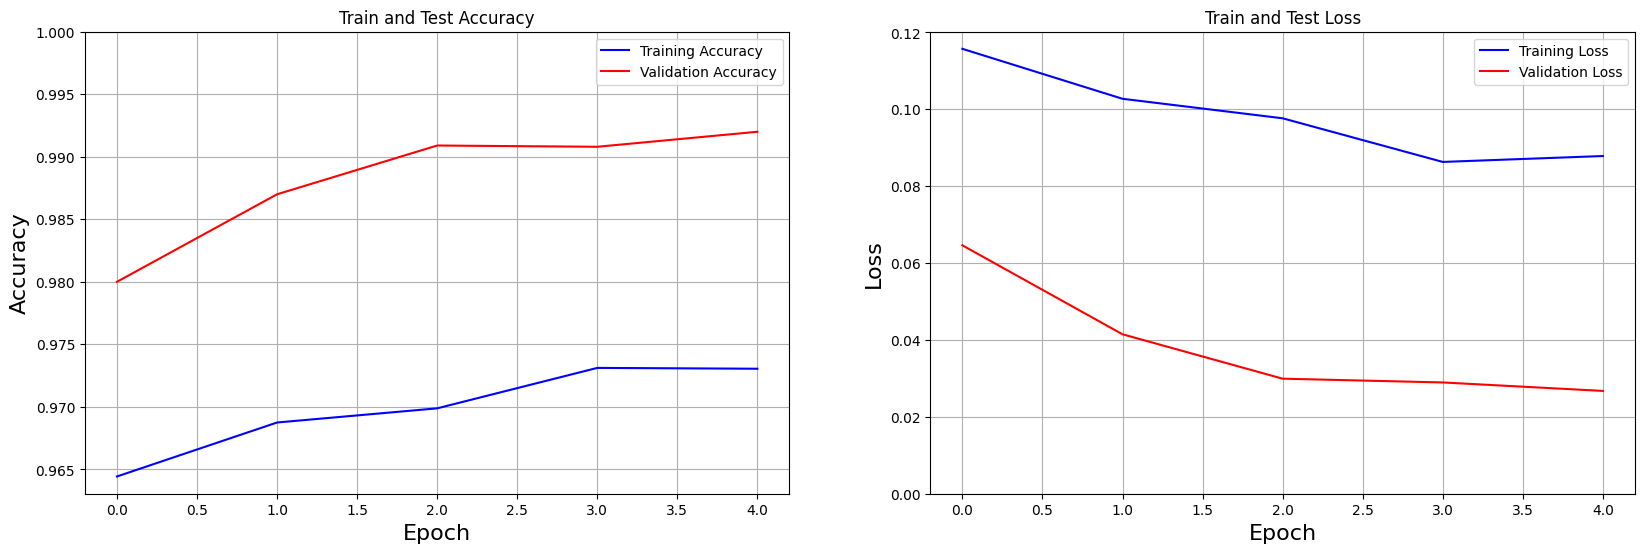

In [68]:
# Train & Test Accuracy and Loss

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], color='b', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='r', label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.ylim([min(plt.ylim()),1])
plt.title('Train and Test Accuracy')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='b', label='Training Loss')
plt.plot(history.history['val_loss'], color='r', label='Validation Loss')
plt.legend()
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.ylim([0,max(plt.ylim())])
plt.title('Train and Test Loss')
plt.grid(True)
plt.show()
# model is overfitting(?)

In [69]:
#evaluating the model using common metrics
loss, precision, recall, acc=model.evaluate(x_test, y_test, verbose=False)
print('Test Accuracy: ', acc)
print('Test Loss: ', loss)
print('Test Precision: ', precision)
print('Test Recall: ', recall)

Test Accuracy:  0.15770000219345093
Test Loss:  2.305126667022705
Test Precision:  0.0
Test Recall:  0.0


In [70]:
# Save the trained model for reuse

model.save('mnist_model.keras')

In [71]:
# Testing Results on random images from test dataset

import random
random = random.randint(0, x_test.shape[0])
random

3369

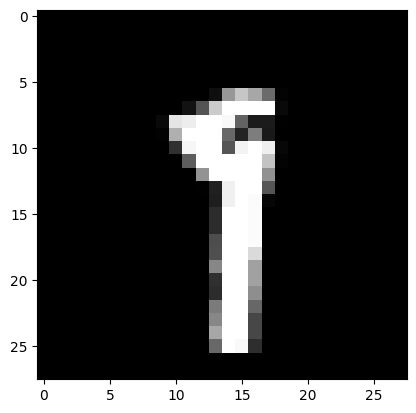

In [72]:
test_image = x_test[random]
y_test[random]

plt.imshow(test_image.reshape(28,28), cmap='gray');

In [73]:
test_data = x_test[random].reshape(1,28,28,1)
probability = model.predict(test_data)
probability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[0.09791487, 0.10526725, 0.10230114, 0.09290785, 0.10160005,
        0.10090066, 0.10538178, 0.09670783, 0.09794089, 0.0990777 ]],
      dtype=float32)

In [74]:
predicted_classes = np.argmax(probability)
predicted_classes

np.int64(6)

In [75]:
print(f'Predicted class: {predicted_classes}')
print(f'Predicted class probability value: {(np.argmax(probability, axis=-1))[0]}')
print(f'Probability values of other classes: \n{probability}')



Predicted class: 6
Predicted class probability value: 6
Probability values of other classes: 
[[0.09791487 0.10526725 0.10230114 0.09290785 0.10160005 0.10090066
  0.10538178 0.09670783 0.09794089 0.0990777 ]]


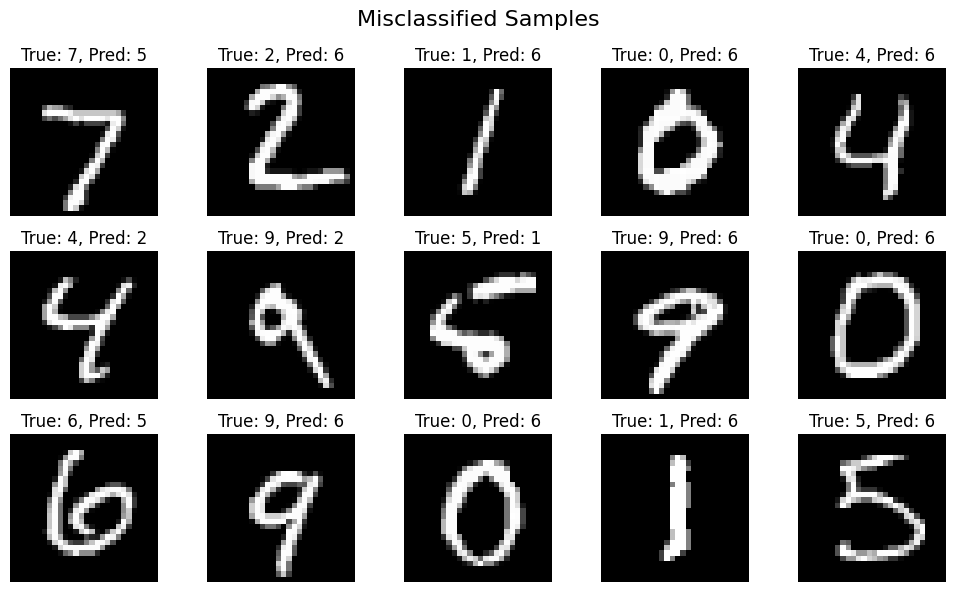

In [76]:
# Misclassified Samples

y_test_labels = np.argmax(y_test, axis=1)

misclassified_idx = np.where(y_pred_class != y_test_labels)[0]

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
fig.suptitle("Misclassified Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    idx = misclassified_idx[i]
    ax.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"True: {y_test_labels[idx]}, Pred: {y_pred_class[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

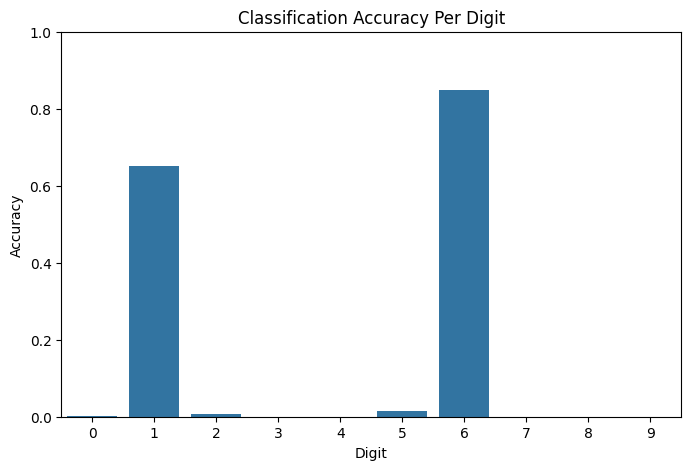

In [77]:
# Classification Accuracy Per Digit

num_classes = 10
class_accuracies = []

for i in range(num_classes):
    correct = np.sum((y_test_labels == i) & (y_pred_class == i))
    total = np.sum(y_test_labels == i)
    accuracy = correct / total if total > 0 else 0
    class_accuracies.append(accuracy)

df = pd.DataFrame({"Digit": range(10), "Accuracy": class_accuracies})

plt.figure(figsize=(8, 5))
sns.barplot(x="Digit", y="Accuracy", data=df)
plt.ylim(0, 1)
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Per Digit")
plt.show()

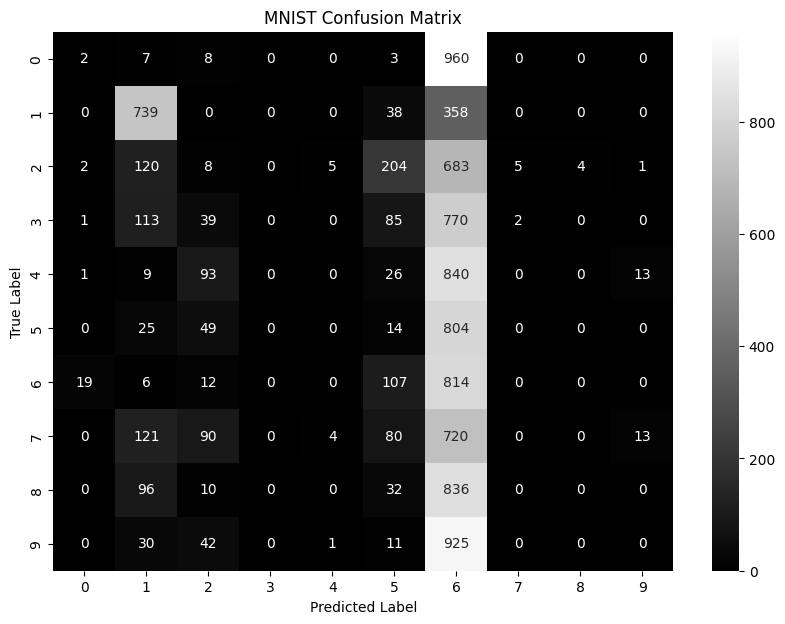

In [78]:
# Confusion Matrix

y_pred_labels = y_pred_class
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="gray", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()